In [2]:
import sys
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#noinspection PyUnresolvedReferences
from model import UNet
#noinspection PyUnresolvedReferences
from dataset import get_dataloader

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


In [4]:
class Discriminator(nn.Module):
    """
    Отличает реальные цвета от сгенерированных
    Вход: цветное изображение 3×128×128
    Выход: вероятность (0 = фейк, 1 = реальное)
    """
    def __init__(self, in_channels=3):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=0),
            nn.AdaptiveAvgPool2d(1),
            nn.Sigmoid()
        )

        # Для feature matching
        self.feature_layers = nn.ModuleList([
            self.layers[0],
            self.layers[2],
            self.layers[4],
        ])

    def forward(self, x):
        return self.layers(x).view(-1, 1)

    def get_features(self, x):
        features = []
        for layer in self.feature_layers:
            x = layer(x)
            features.append(x)
        return features

In [5]:
criterion_gan = nn.BCELoss()  # Binary Cross Entropy (для дискриминатора)

def adversarial_loss(predictions, targets):
    """
    predictions: что предсказал дискриминатор
    targets: чего мы хотим (1 = реальное, 0 = фейк)
    """
    return criterion_gan(predictions, targets)

In [6]:
class FeatureMatchingLoss(nn.Module):
    def __init__(self, discriminator):
        super().__init__()
        self.discriminator = discriminator
        self.mse = nn.MSELoss()

    def forward(self, fake, real):
        # Берём промежуточные слои дискриминатора
        fake_features = self.discriminator.get_features(fake)
        real_features = self.discriminator.get_features(real)

        loss = 0
        for f_fake, f_real in zip(fake_features, real_features):
            loss += self.mse(f_fake, f_real.detach())
        return loss

In [7]:
def show_prediction(generator, gray_batch, color_batch, epoch):
    generator.eval()
    with torch.no_grad():
        gray_batch = gray_batch.to(device)
        pred_batch = generator(gray_batch)

        # Нормализация для показа
        pred_img = pred_batch[0].cpu().permute(1, 2, 0).numpy()
        pred_img = (pred_img + 1) / 2  # из [-1,1] → [0,1]
        pred_img = np.clip(pred_img, 0, 1)

        gray_img = gray_batch[0].cpu().squeeze().numpy()
        true_img = color_batch[0].cpu().permute(1, 2, 0).numpy()

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(gray_img, cmap='gray')
        axes[0].set_title("Вход (ч/б)")
        axes[0].axis('off')

        axes[1].imshow(pred_img)
        axes[1].set_title(f"Предсказание GAN (эпоха {epoch})")
        axes[1].axis('off')

        axes[2].imshow(true_img)
        axes[2].set_title("Реальное цветное")
        axes[2].axis('off')

        plt.show()

    generator.train()

In [8]:
data_dir = '../data/processed/test'
train_loader = get_dataloader(data_dir, batch_size=8, shuffle=True)

print(f"Загружено {len(train_loader.dataset)} изображений")
print(f"Батчей: {len(train_loader)}")

Загружено 2 изображений
Батчей: 1


In [9]:
# Генератор (наша U-Net с Tanh на выходе)
generator = UNet(in_channels=1, out_channels=3).to(device)

# Дискриминатор
discriminator = Discriminator(in_channels=3).to(device)

feature_matching_loss = FeatureMatchingLoss(discriminator)

# Функция потерь для пиксельной точности
criterion_mse = nn.MSELoss()

# Два отдельных оптимизатора
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

print("✅ Модели созданы")
print(f"   Генератор: {sum(p.numel() for p in generator.parameters()):,} параметров")
print(f"   Дискриминатор: {sum(p.numel() for p in discriminator.parameters()):,} параметров")

✅ Модели созданы
   Генератор: 31,042,499 параметров
   Дискриминатор: 168,033 параметров


Начинаем обучение GAN...

✅ Эпоха 1 завершена | Gen Loss: 2.9393 | Disc Loss: 0.7066
✅ Эпоха 2 завершена | Gen Loss: 2.5089 | Disc Loss: 0.6864
✅ Эпоха 3 завершена | Gen Loss: 2.2484 | Disc Loss: 0.6756


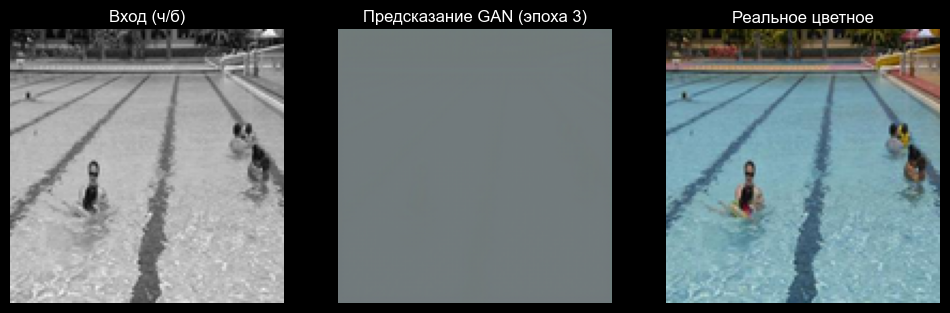

✅ Эпоха 4 завершена | Gen Loss: 1.9976 | Disc Loss: 0.6628
✅ Эпоха 5 завершена | Gen Loss: 1.7548 | Disc Loss: 0.6511
✅ Эпоха 6 завершена | Gen Loss: 1.5222 | Disc Loss: 0.6353


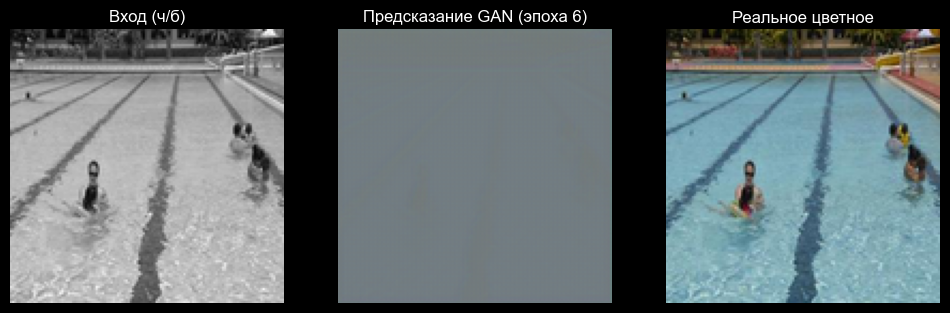

✅ Эпоха 7 завершена | Gen Loss: 1.2994 | Disc Loss: 0.6244
✅ Эпоха 8 завершена | Gen Loss: 1.0846 | Disc Loss: 0.6154
✅ Эпоха 9 завершена | Gen Loss: 0.9075 | Disc Loss: 0.6106


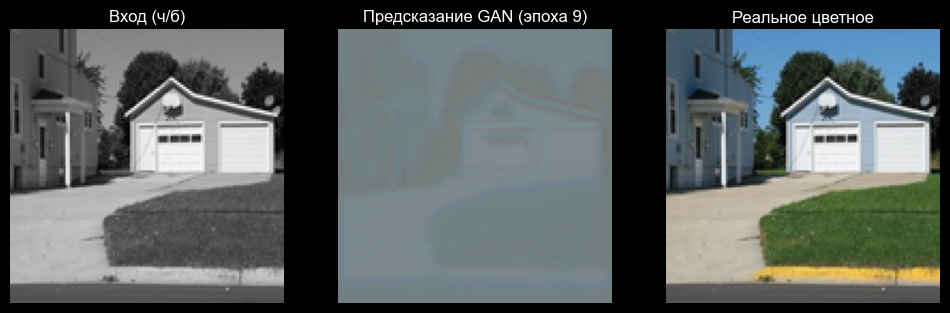

✅ Эпоха 10 завершена | Gen Loss: 0.7640 | Disc Loss: 0.6052
✅ Эпоха 11 завершена | Gen Loss: 0.6656 | Disc Loss: 0.6011
✅ Эпоха 12 завершена | Gen Loss: 0.6603 | Disc Loss: 0.5914


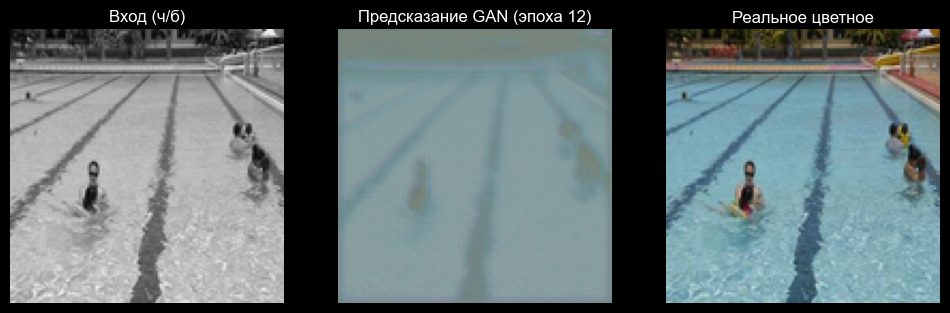

✅ Эпоха 13 завершена | Gen Loss: 0.6084 | Disc Loss: 0.5857
✅ Эпоха 14 завершена | Gen Loss: 0.5363 | Disc Loss: 0.5777
✅ Эпоха 15 завершена | Gen Loss: 0.4930 | Disc Loss: 0.5697


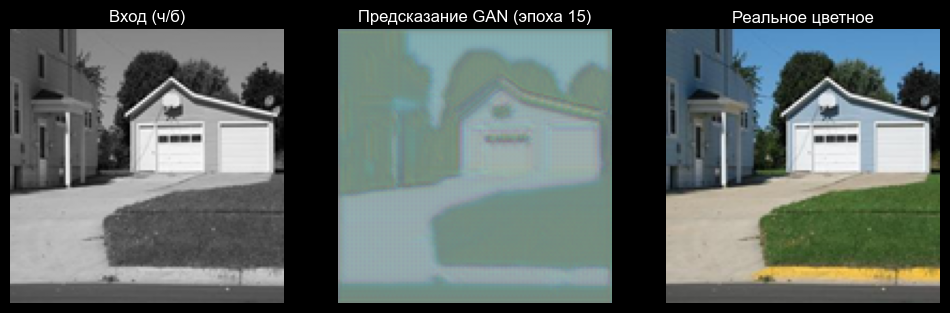

✅ Эпоха 16 завершена | Gen Loss: 0.4601 | Disc Loss: 0.5631
✅ Эпоха 17 завершена | Gen Loss: 0.4308 | Disc Loss: 0.5548
✅ Эпоха 18 завершена | Gen Loss: 0.4062 | Disc Loss: 0.5449


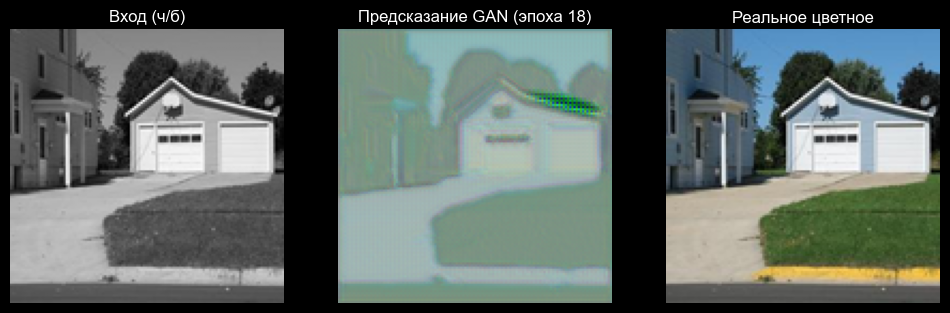

✅ Эпоха 19 завершена | Gen Loss: 0.3812 | Disc Loss: 0.5387
✅ Эпоха 20 завершена | Gen Loss: 0.3581 | Disc Loss: 0.5300
✅ Эпоха 21 завершена | Gen Loss: 0.3388 | Disc Loss: 0.5227


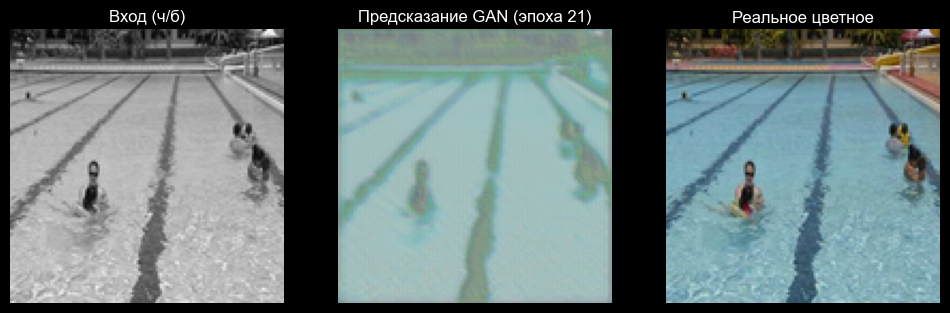

✅ Эпоха 22 завершена | Gen Loss: 0.3204 | Disc Loss: 0.5134
✅ Эпоха 23 завершена | Gen Loss: 0.3026 | Disc Loss: 0.5062
✅ Эпоха 24 завершена | Gen Loss: 0.2864 | Disc Loss: 0.4977


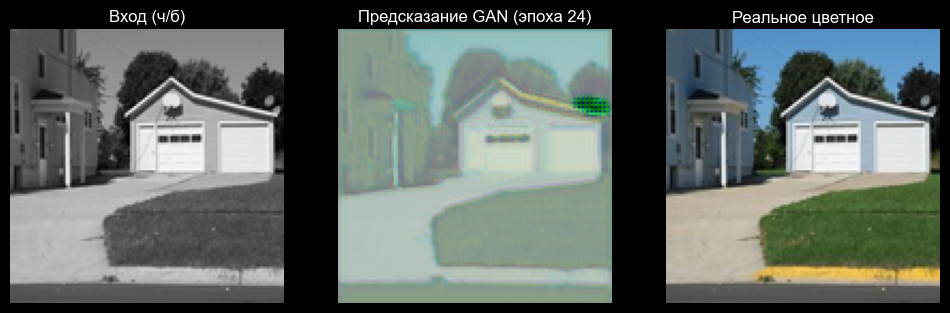

✅ Эпоха 25 завершена | Gen Loss: 0.2718 | Disc Loss: 0.4916
✅ Эпоха 26 завершена | Gen Loss: 0.2590 | Disc Loss: 0.4830
✅ Эпоха 27 завершена | Gen Loss: 0.2478 | Disc Loss: 0.4794


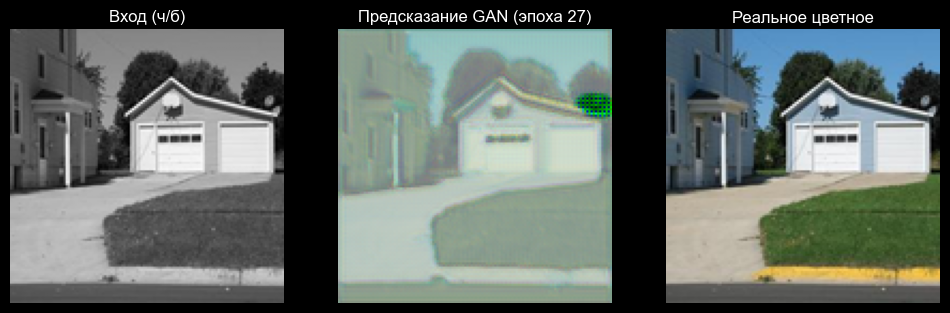

✅ Эпоха 28 завершена | Gen Loss: 0.2378 | Disc Loss: 0.4694
✅ Эпоха 29 завершена | Gen Loss: 0.2288 | Disc Loss: 0.4624
✅ Эпоха 30 завершена | Gen Loss: 0.2203 | Disc Loss: 0.4555


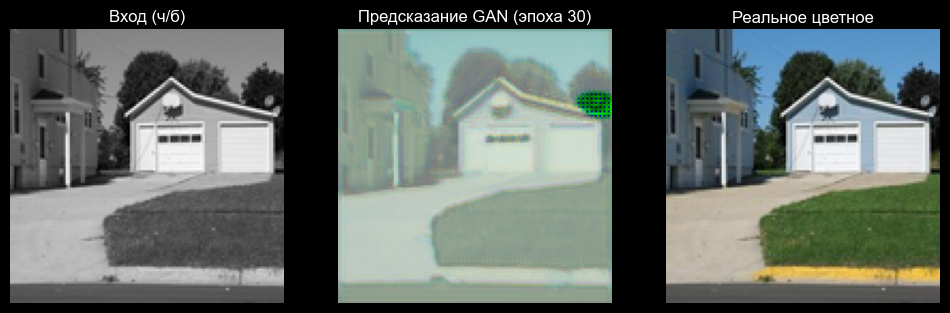

In [10]:
num_epochs = 30
lambda_mse = 5  # Вес MSE-потери
lambda_gan = 0.1

generator_losses = []
discriminator_losses = []

print("Начинаем обучение GAN...\n")

for epoch in range(num_epochs):
    epoch_gen_loss = 0.0
    epoch_disc_loss = 0.0

    for batch_idx, (gray_batch, color_batch) in enumerate(train_loader):
        real_batch = color_batch.to(device)
        gray_batch = gray_batch.to(device)

        batch_size = real_batch.size(0)

        # Метки для дискриминатора
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device) + 0.1

        noise = torch.randn_like(gray_batch) * 0.05
        gray_batch_noisy = gray_batch + noise

        # ========== ОБУЧЕНИЕ ДИСКРИМИНАТОРА ==========
        loss_D = 0
        if batch_idx % 3 == 0:
            optimizer_D.zero_grad()

            # Реальные изображения → дискриминатор должен сказать "1"
            real_output = discriminator(real_batch)
            loss_real = adversarial_loss(real_output, real_labels)

            # Сгенерированные изображения → дискриминатор должен сказать "0"
            fake_batch = generator(gray_batch_noisy).detach()  # detach() чтобы не обучать генератор
            fake_output = discriminator(fake_batch)
            loss_fake = adversarial_loss(fake_output, fake_labels)

            # Общая потеря дискриминатора
            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            optimizer_D.step()

        # ========== ОБУЧЕНИЕ ГЕНЕРАТОРА ==========
        optimizer_G.zero_grad()

        fake_batch = generator(gray_batch_noisy)

        # 1. Adversarial loss (пытаемся обмануть дискриминатор)
        loss_G_feature = feature_matching_loss(fake_batch, real_batch)

        # 2. MSE loss (пиксельная точность)
        loss_G_mse = criterion_mse(fake_batch, real_batch)

        # Итоговая потеря генератора
        loss_G_feature = feature_matching_loss(fake_batch, real_batch)
        loss_G = lambda_mse * loss_G_mse + lambda_gan * loss_G_feature
        loss_G.backward()
        optimizer_G.step()

        # Сохраняем потери
        epoch_gen_loss += loss_G.item()
        epoch_disc_loss += loss_D.item()

        # Вывод прогресса
        if (batch_idx + 1) % 50 == 0:
            print(f"Эпоха {epoch+1}/{num_epochs} | Батч {batch_idx+1}/{len(train_loader)}")
            print(f"   Loss G: {loss_G.item():.4f} (Adv: {loss_G_feature.item():.4f}, MSE: {loss_G_mse.item():.4f})")
            print(f"   Loss D: {loss_D.item():.4f}")

    # Средние потери за эпоху
    avg_gen_loss = epoch_gen_loss / len(train_loader)
    avg_disc_loss = epoch_disc_loss / len(train_loader)
    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)

    print(f"✅ Эпоха {epoch+1} завершена | Gen Loss: {avg_gen_loss:.4f} | Disc Loss: {avg_disc_loss:.4f}")

    # Показываем результат каждые 3 эпохи
    if (epoch + 1) % 3 == 0:
        gray_batch, color_batch = next(iter(train_loader))
        show_prediction(generator, gray_batch, color_batch, epoch + 1)


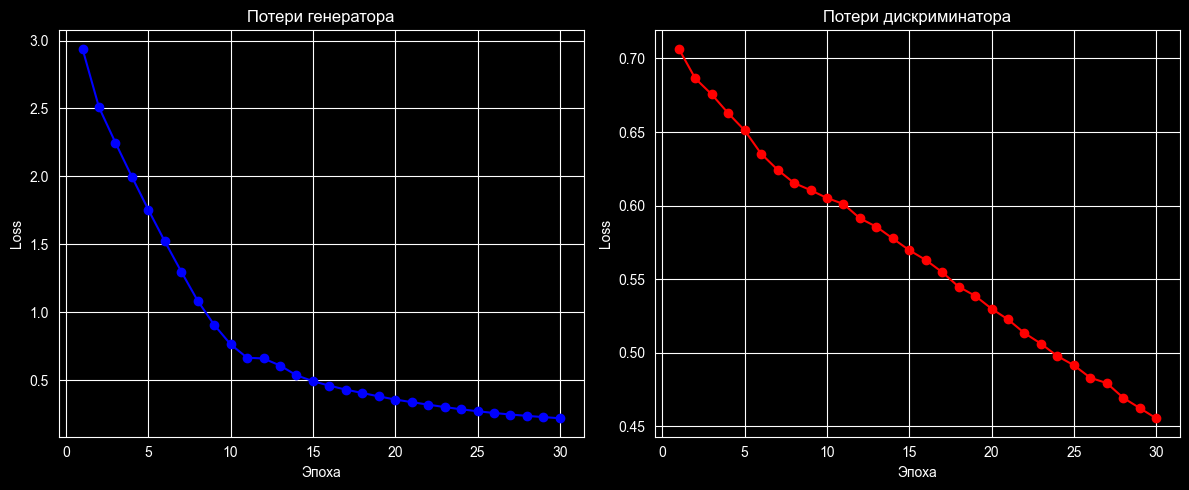

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), generator_losses, marker='o', color='blue')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Потери генератора')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), discriminator_losses, marker='o', color='red')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Потери дискриминатора')
plt.grid(True)

plt.tight_layout()
plt.show()